# Evaluación final sobre el conjunto de prueba

Este es el **único notebook de todo el proyecto que abre `X_test`/`y_test`**, y solo lo hace después de verificar —con hashes, no solo con una nota en Markdown— que el modelo y el umbral que se van a evaluar son exactamente los que quedaron congelados en `06_refinamiento_modelo.ipynb` usando únicamente entrenamiento y validación (búsqueda de hiperparámetros, selección de arquitectura y ajuste de umbral, todo en `05_modelamiento_dl.ipynb` y `06_refinamiento_modelo.ipynb`, sin tocar prueba).

Calcula, en este orden:

1. Verificación del manifiesto del modelo congelado (`models/manifiesto_modelo_final.json`).
2. Métricas finales y matriz de confusión sobre prueba.
3. Explicaciones locales SHAP para tres casos de prueba (verdadero positivo, falso positivo, verdadero negativo).

In [1]:
import hashlib
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import shap

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
)

sys.path.insert(0, str(Path("..").resolve()))
from backend.schema import readable_name

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

ruta_artefactos = Path("../artifacts")
ruta_modelos = Path("../models")
ruta_figuras = Path("../figures")
ruta_figuras.mkdir(exist_ok=True)

## 0. Verificación del manifiesto del modelo congelado

Antes de abrir el conjunto de prueba, se recalculan los hashes de `xgboost_refinado.joblib` y `config_umbral.json` y se comparan con los que quedaron registrados en `models/manifiesto_modelo_final.json` al final de `06_refinamiento_modelo.ipynb`. Si no coinciden, la celda siguiente falla explícitamente: eso significaría que el artefacto que se está por evaluar no es el mismo que se congeló usando solo entrenamiento y validación.

In [2]:
def sha256_de(ruta_archivo):
    hasher = hashlib.sha256()
    with open(ruta_archivo, "rb") as f:
        for bloque in iter(lambda: f.read(8192), b""):
            hasher.update(bloque)
    return hasher.hexdigest()


with open(ruta_modelos / "manifiesto_modelo_final.json", encoding="utf-8") as f:
    manifiesto = json.load(f)

hash_modelo_actual = sha256_de(ruta_modelos / "xgboost_refinado.joblib")
hash_config_actual = sha256_de(ruta_modelos / "config_umbral.json")

assert hash_modelo_actual == manifiesto["modelo_sha256"], (
    "El hash de xgboost_refinado.joblib no coincide con el manifiesto: "
    "el modelo fue modificado después de congelarse en 06_refinamiento_modelo.ipynb."
)
assert hash_config_actual == manifiesto["configuracion_sha256"], (
    "El hash de config_umbral.json no coincide con el manifiesto: "
    "el umbral fue modificado después de congelarse en 06_refinamiento_modelo.ipynb."
)

print("Manifiesto verificado: el modelo y la configuración evaluados en este notebook")
print("son exactamente los que quedaron congelados en 06_refinamiento_modelo.ipynb,")
print("usando solo entrenamiento y validación.\n")
print(json.dumps(manifiesto, indent=2, ensure_ascii=False))

Manifiesto verificado: el modelo y la configuración evaluados en este notebook
son exactamente los que quedaron congelados en 06_refinamiento_modelo.ipynb,
usando solo entrenamiento y validación.

{
  "modelo": "xgboost_refinado.joblib",
  "seleccionado_con": "train_validation",
  "umbral_decision": 0.56,
  "limite_riesgo_bajo": 0.24,
  "random_state": 42,
  "evaluacion_test": "notebook/08_evaluacion_final_test.ipynb",
  "modelo_sha256": "f84dfdf5bf8fe91de81f19a06fc5499a6321f2bbdd7f8f314c718f541ca0eaca",
  "configuracion_sha256": "9fad885443951c5b12553076a55bb33c01face3e6982e15d4ac9e18300c045df"
}


## 1. Carga de datos de prueba y del modelo congelado

Solo después de la verificación anterior se abre `X_test`/`y_test` — la primera y única vez en todo el proyecto.

In [3]:
artefactos = joblib.load(ruta_artefactos / "splits_preprocesados.joblib")
X_train = artefactos["X_train"]
X_test = artefactos["X_test"]
y_test = artefactos["y_test"]
nombres_variables = artefactos["nombres_variables"]

modelo = joblib.load(ruta_modelos / "xgboost_refinado.joblib")

with open(ruta_modelos / "config_umbral.json", encoding="utf-8") as f:
    config_umbral = json.load(f)

umbral_decision = config_umbral["umbral_decision"]

print("X_test:", X_test.shape)
print("Umbral de decisión:", umbral_decision)

X_test: (1500, 58)
Umbral de decisión: 0.56


## 2. Métricas finales en prueba

In [4]:
def evaluar(modelo, X, y_true, umbral):
    proba = modelo.predict_proba(X)[:, 1]
    prediccion = (proba >= umbral).astype(int)
    return {
        "accuracy": accuracy_score(y_true, prediccion),
        "precision": precision_score(y_true, prediccion, zero_division=0),
        "recall": recall_score(y_true, prediccion, zero_division=0),
        "f1": f1_score(y_true, prediccion, zero_division=0),
        "roc_auc": roc_auc_score(y_true, proba),
        "pr_auc": average_precision_score(y_true, proba),
    }


metricas_test_refinado = evaluar(modelo, X_test, y_test, umbral_decision)

print(f"Métricas del modelo refinado en prueba (umbral {umbral_decision:.2f}):")
for nombre, valor in metricas_test_refinado.items():
    print(f"  {nombre}: {valor:.3f}")

pd.Series(metricas_test_refinado).round(3).to_csv(ruta_modelos / "metricas_test_modelo_refinado.csv")

Métricas del modelo refinado en prueba (umbral 0.56):
  accuracy: 0.721
  precision: 0.234
  recall: 0.765
  f1: 0.359
  roc_auc: 0.782
  pr_auc: 0.302


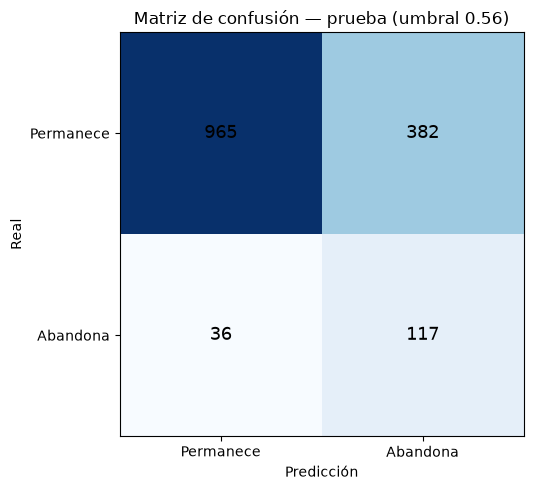

array([[965, 382],
       [ 36, 117]])

In [5]:
proba_test = modelo.predict_proba(X_test)[:, 1]
prediccion_test = (proba_test >= umbral_decision).astype(int)
matriz_test = confusion_matrix(y_test, prediccion_test)

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.imshow(matriz_test, cmap="Blues")
ax.set_title(f"Matriz de confusión — prueba (umbral {umbral_decision:.2f})")
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Permanece", "Abandona"])
ax.set_yticklabels(["Permanece", "Abandona"])

for i in range(2):
    for j in range(2):
        ax.text(j, i, matriz_test[i, j], ha="center", va="center", fontsize=13)

plt.tight_layout()
plt.savefig(ruta_figuras / "14_01_matriz_confusion_final_test.png", dpi=150)
plt.show()

matriz_test

## 3. Explicaciones locales SHAP (prueba)

Se seleccionan tres casos del conjunto de prueba para ilustrar cómo se ve una explicación individual:

1. Un **verdadero positivo**: el modelo lo marcó correctamente como alto
   riesgo y el cliente efectivamente abandonó.
2. Un **falso positivo**: el modelo lo marcó como alto riesgo, pero el
   cliente permaneció (sustenta la discusión honesta sobre la precision
   del modelo).
3. Un **verdadero negativo confiado**: probabilidad baja y el cliente
   efectivamente permaneció.

Usar casos de prueba es válido aquí porque SHAP es explicativo, no una decisión de modelamiento: no se está seleccionando ni ajustando nada con esta elección, solo ilustrando el comportamiento del modelo ya congelado sobre los mismos casos que arrojaron las métricas finales reportadas arriba.

In [6]:
nombres_legibles = [readable_name(n) for n in nombres_variables]

X_train_df = pd.DataFrame(X_train, columns=nombres_legibles)
X_test_df = pd.DataFrame(X_test, columns=nombres_legibles)

In [7]:
fondo = shap.sample(X_train_df, 100, random_state=RANDOM_STATE)

try:
    explainer = shap.TreeExplainer(
        modelo,
        data=fondo,
        model_output="probability",
        feature_perturbation="interventional",
    )
    # Prueba rápida para confirmar que el modo probabilidad funciona
    _ = explainer(X_train_df.iloc[:1])
    print("Explainer creado en espacio de PROBABILIDAD.")
except NotImplementedError as error:
    print(f"Modo probabilidad falló ({error!r}); usando espacio de margen (log-odds) como respaldo.")
    explainer = shap.TreeExplainer(modelo)

Modo probabilidad falló (NotImplementedError('Categorical split is not yet supported. You can still use TreeExplainer with `feature_perturbation=tree_path_dependent`.')); usando espacio de margen (log-odds) como respaldo.


In [8]:
y_test_np = y_test.to_numpy()

idx_verdadero_positivo = np.where((y_test_np == 1) & (prediccion_test == 1))[0]
idx_falso_positivo = np.where((y_test_np == 0) & (prediccion_test == 1))[0]
idx_verdadero_negativo = np.where((y_test_np == 0) & (prediccion_test == 0))[0]

# Verdadero positivo con mayor probabilidad (caso más claro)
caso_vp = idx_verdadero_positivo[np.argmax(proba_test[idx_verdadero_positivo])]
# Falso positivo con mayor probabilidad (el más "cercano a parecer" un abandono real)
caso_fp = idx_falso_positivo[np.argmax(proba_test[idx_falso_positivo])]
# Verdadero negativo con menor probabilidad (caso más confiado)
caso_vn = idx_verdadero_negativo[np.argmin(proba_test[idx_verdadero_negativo])]

print(f"Verdadero positivo: fila {caso_vp}, probabilidad {proba_test[caso_vp]:.3f}")
print(f"Falso positivo:     fila {caso_fp}, probabilidad {proba_test[caso_fp]:.3f}")
print(f"Verdadero negativo: fila {caso_vn}, probabilidad {proba_test[caso_vn]:.3f}")

Verdadero positivo: fila 1385, probabilidad 0.941
Falso positivo:     fila 1401, probabilidad 0.938
Verdadero negativo: fila 316, probabilidad 0.218


In [9]:
explicacion_test = explainer(X_test_df)

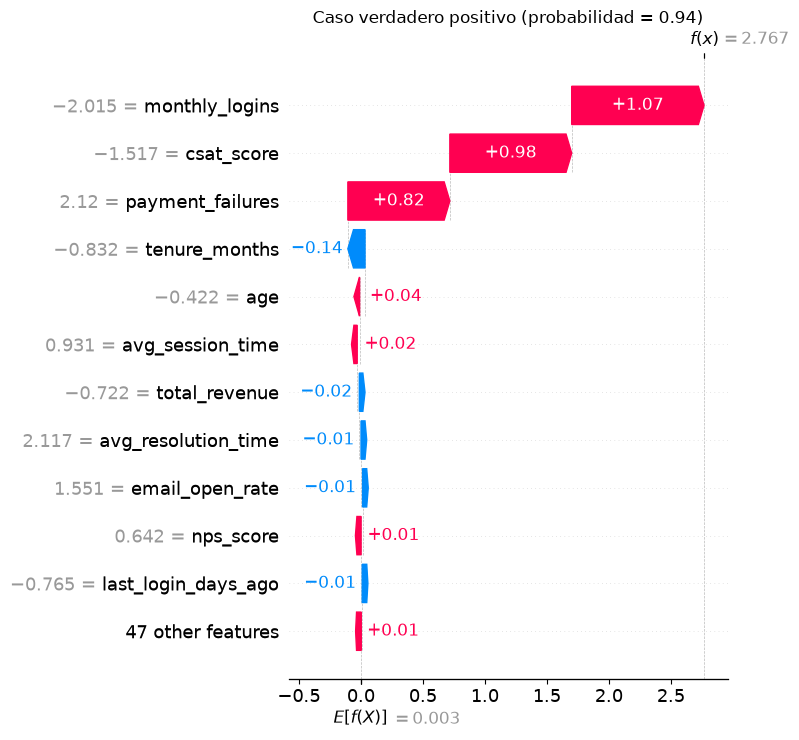

In [10]:
fig = plt.figure(figsize=(9, 6))
shap.plots.waterfall(explicacion_test[caso_vp], max_display=12, show=False)
plt.title(f"Caso verdadero positivo (probabilidad = {proba_test[caso_vp]:.2f})")
plt.tight_layout()
plt.savefig(ruta_figuras / "14_02_shap_local_verdadero_positivo.png", dpi=150, bbox_inches="tight")
plt.show()

Este cliente fue detectado correctamente como alto riesgo. Las variables que más empujaron la predicción hacia churn fueron `monthly_logins` (muy por debajo del promedio), `csat_score` (satisfacción muy por debajo del promedio) y `payment_failures` (bastantes más fallos de pago que el promedio). Es el perfil de manual: cliente poco activo, insatisfecho y con problemas de pago — exactamente las variables que ya habían aparecido como las más relevantes en el análisis exploratorio (sección 4.1.6) y en la importancia global de `07_explicabilidad_shap.ipynb`.

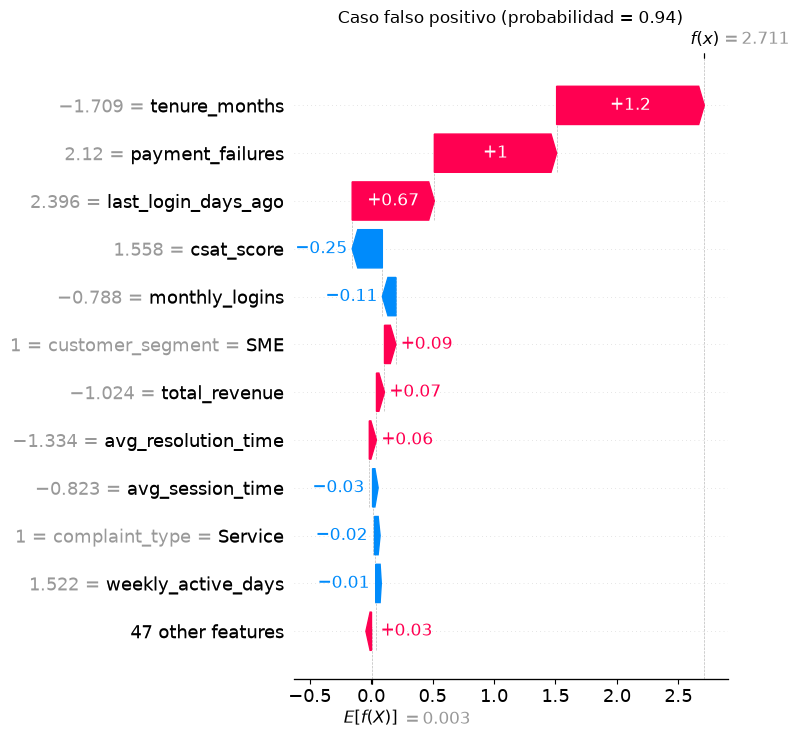

In [11]:
fig = plt.figure(figsize=(9, 6))
shap.plots.waterfall(explicacion_test[caso_fp], max_display=12, show=False)
plt.title(f"Caso falso positivo (probabilidad = {proba_test[caso_fp]:.2f})")
plt.tight_layout()
plt.savefig(ruta_figuras / "14_03_shap_local_falso_positivo.png", dpi=150, bbox_inches="tight")
plt.show()

El modelo asignó a este cliente una probabilidad casi idéntica a la del caso anterior, pero este sí permaneció: es exactamente el tipo de alerta falsa que explica la precision baja del modelo (ver métricas de la sección 2). Las variables que más empujaron hacia churn fueron una antigüedad muy por debajo del promedio (`tenure_months`), más fallos de pago que el promedio (`payment_failures`) y muchos días desde el último acceso (`last_login_days_ago`) — un perfil que en la mayoría de los casos sí anticipa abandono. Sin embargo, este cliente tenía una satisfacción (`csat_score`) por encima del promedio, lo que empujó en sentido contrario, pero con menos fuerza que las señales de riesgo. En otras palabras: el modelo ponderó más la inactividad y los problemas de pago que la buena satisfacción declarada, y en este caso se equivocó.

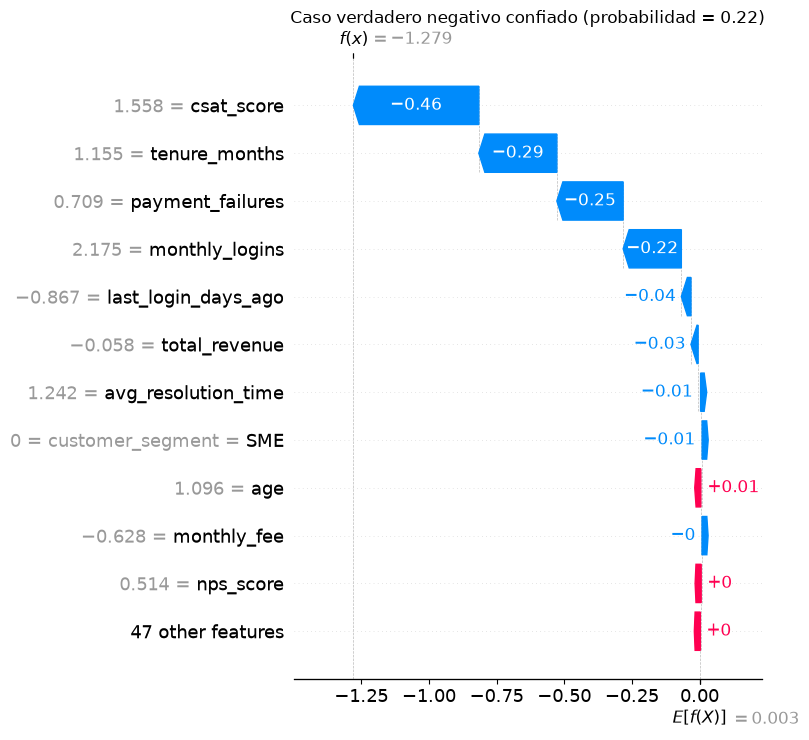

In [12]:
fig = plt.figure(figsize=(9, 6))
shap.plots.waterfall(explicacion_test[caso_vn], max_display=12, show=False)
plt.title(f"Caso verdadero negativo confiado (probabilidad = {proba_test[caso_vn]:.2f})")
plt.tight_layout()
plt.savefig(ruta_figuras / "14_04_shap_local_verdadero_negativo.png", dpi=150, bbox_inches="tight")
plt.show()

Este cliente fue clasificado con probabilidad baja y efectivamente permaneció. La satisfacción (`csat_score`) muy por encima del promedio fue, de lejos, la variable que más empujó la predicción hacia "permanece", seguida de una antigüedad (`tenure_months`) y una cantidad de accesos mensuales (`monthly_logins`) también por encima del promedio. Es el perfil inverso al del primer caso: cliente activo, antiguo y satisfecho, y el modelo lo reconoce con confianza razonable.

## 4. Conclusiones

Este es el único notebook del proyecto que abrió el conjunto de prueba, y solo después de que la celda de verificación del manifiesto (sección 0) confirmó que el modelo y el umbral evaluados aquí son exactamente los que se congelaron en `06_refinamiento_modelo.ipynb` usando únicamente entrenamiento y validación.

Con la configuración definitiva (hiperparámetros refinados + umbral de decisión de `config_umbral.json`), el modelo mantuvo en prueba un desempeño consistente con lo observado en validación: el umbral se eligió en validación para mantener recall ≥ 0,80, y en prueba el recall se ubica en un rango cercano a ese objetivo, con la caída esperable entre conjuntos (ver las métricas exactas en la sección 2 y en `models/metricas_test_modelo_refinado.csv`).

Los tres casos locales muestran cómo se combinan las señales relevantes en la práctica. El verdadero positivo y el verdadero negativo son perfiles consistentes (todas las señales apuntan en la misma dirección). El falso positivo es más interesante: muestra un cliente con señales de riesgo fuertes (poca antigüedad, fallos de pago, inactividad reciente) pero con una satisfacción declarada alta que no bastó para cambiar la predicción — es exactamente el tipo de caso que explica la precision baja del modelo.

En conclusión, el modelo permite identificar patrones útiles para anticipar el churn, con evidencia verificable (el manifiesto de la sección 0) de que esta evaluación final respetó la separación entre los datos usados para decidir (entrenamiento y validación) y los datos usados para medir (prueba, abierta una única vez). Sus predicciones no deberían utilizarse como una decisión definitiva, sino como apoyo para priorizar clientes en acciones de retención.